In [29]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import random
from skimage.filters import threshold_sauvola, threshold_niblack
from joblib import Parallel, delayed
import json
from datetime import datetime
import IPython.display as display
from PIL import Image
import io
import time

%matplotlib inline

In [30]:
# Set your image path here (used across subsequent cells)
IMAGE_PATH = r"C:\Users\PC-LAB1\img_processing_lab\images\image_with_shapes_2.jpeg" 

# Load image in BGR format
image_bgr = cv2.imread(IMAGE_PATH)

if image_bgr is None:
    # Create a dummy synthetic binary/color image if file doesn't exist for demonstration
    image_bgr = np.zeros((300, 300, 3), dtype=np.uint8)
    # Draw a colored rectangle shape
    cv2.rectangle(image_bgr, (50, 50), (200, 220), (50, 180, 240), -1)
    # Draw a circle shape
    cv2.circle(image_bgr, (220, 200), 40, (100, 255, 100), -1)
    print("Using a generated sample image.")
else:
    print(f"Successfully loaded image from: {IMAGE_PATH}")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

Successfully loaded image from: C:\Users\PC-LAB1\img_processing_lab\images\image_with_shapes_2.jpeg


In [31]:
# Otsu's thresholding to isolate foreground objects/contours
_, binary_mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Find contours (objects in image)
contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Select the largest contour for demonstration
main_contour = max(contours, key=cv2.contourArea)

# Create a mask dedicated to the selected contour
object_mask = np.zeros(gray.shape, dtype=np.uint8)
cv2.drawContours(object_mask, [main_contour], -1, 255, cv2.FILLED)

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], shape=(577, 576), dtype=uint8)

In [32]:
# 1. Area
area = cv2.contourArea(main_contour)

# 2. Perimeter
perimeter = cv2.arcLength(main_contour, True)

# 3. Bounding Box
x, y, w, h = cv2.boundingRect(main_contour)

# 4. Centroid
M = cv2.moments(main_contour)
if M["m00"] != 0:
    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])
else:
    cx, cy = 0, 0

# 5. Aspect Ratio
aspect_ratio = float(w) / h if h != 0 else 0.0

# 6. Extent (Ratio of contour area to bounding rectangle area)
rect_area = w * h
extent = float(area) / rect_area if rect_area != 0 else 0.0

# 7. Compactness / Form Factor (4 * pi * area / perimeter^2)
compactness = (4 * np.pi * area) / (perimeter ** 2) if perimeter != 0 else 0.0

# 8. Solidity (Ratio of contour area to its convex hull area)
hull = cv2.convexHull(main_contour)
hull_area = cv2.contourArea(hull)
solidity = float(area) / hull_area if hull_area != 0 else 0.0

# 9. Equivalent Diameter
equivalent_diameter = np.sqrt(4 * area / np.pi)

In [33]:
# 1. Intensity Mean & Standard Deviation (Grayscale over region mask)
mean_intensity = float(cv2.mean(gray, mask=object_mask)[0])
std_intensity = float(gray[object_mask == 255].std()) if np.sum(object_mask) > 0 else 0.0

# 2. Mean BGR Channel Values
mean_b, mean_g, mean_r = cv2.mean(image_bgr, mask=object_mask)[:3]

# 3. HSV Representation (Mean Hue, Saturation, Value)
image_hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
mean_h, mean_s, mean_v = cv2.mean(image_hsv, mask=object_mask)[:3]

# 4. Dominant Color Estimation (Mean in LAB Color Space for perceptual metrics)
image_lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
mean_l, mean_a, mean_b_lab = cv2.mean(image_lab, mask=object_mask)[:3]

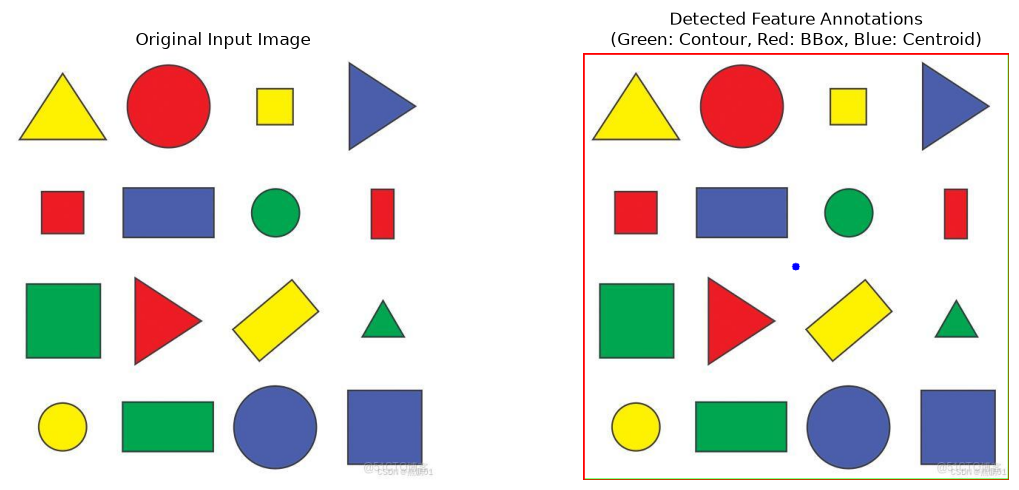

,Category,Feature Name,Value
0,Geometric,Area,331200.00
1,Geometric,Perimeter,2302.00
2,Geometric,"Bounding Box (x, y, w, h)","(0, 0, 576, 577)"
3,Geometric,"Centroid (cx, cy)","(287, 288)"
4,Geometric,Aspect Ratio,0.9983
5,Geometric,Extent,0.9965
6,Geometric,Compactness,0.7854
7,Geometric,Solidity,1.0000
8,Geometric,Equivalent Diameter,649.38
9,Color/Intensity,Mean Intensity (Gray),212.81


In [34]:
# Prepare visualization image with overlayed features
annotated_img = image_rgb.copy()

# Draw contour (green outline)
cv2.drawContours(annotated_img, [main_contour], -1, (0, 255, 0), 2)

# Draw Bounding Box (red)
cv2.rectangle(annotated_img, (x, y), (x + w, y + h), (255, 0, 0), 2)

# Draw Centroid (blue point)
cv2.circle(annotated_img, (cx, cy), 5, (0, 0, 255), -1)

# Display Visuals
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(image_rgb)
axes[0].set_title("Original Input Image")
axes[0].axis("off")

axes[1].imshow(annotated_img)
axes[1].set_title("Detected Feature Annotations\n(Green: Contour, Red: BBox, Blue: Centroid)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# Aggregate Features into a Pandas DataFrame for concise tabular display
features_dict = {
    "Category": [
        "Geometric", "Geometric", "Geometric", "Geometric", 
        "Geometric", "Geometric", "Geometric", "Geometric", "Geometric",
        "Color/Intensity", "Color/Intensity", "Color/Intensity", 
        "Color/Intensity", "Color/Intensity", "Color/Intensity"
    ],
    "Feature Name": [
        "Area", "Perimeter", "Bounding Box (x, y, w, h)", "Centroid (cx, cy)",
        "Aspect Ratio", "Extent", "Compactness", "Solidity", "Equivalent Diameter",
        "Mean Intensity (Gray)", "Std Dev Intensity (Gray)", "Mean RGB Values (R, G, B)",
        "Mean HSV Values (H, S, V)", "Mean LAB Values (L, A, B)", "Bounding Box Area"
    ],
    "Value": [
        f"{area:.2f}",
        f"{perimeter:.2f}",
        f"({x}, {y}, {w}, {h})",
        f"({cx}, {cy})",
        f"{aspect_ratio:.4f}",
        f"{extent:.4f}",
        f"{compactness:.4f}",
        f"{solidity:.4f}",
        f"{equivalent_diameter:.2f}",
        f"{mean_intensity:.2f}",
        f"{std_intensity:.2f}",
        f"({mean_r:.1f}, {mean_g:.1f}, {mean_b:.1f})",
        f"({mean_h:.1f}, {mean_s:.1f}, {mean_v:.1f})",
        f"({mean_l:.1f}, {mean_a:.1f}, {mean_b_lab:.1f})",
        f"{rect_area}"
    ]
}

df_features = pd.DataFrame(features_dict)

# Explicitly import display from IPython.display to resolve the error:
from IPython.display import display
display(df_features)

# Alternatively, if running as a pure Python script without IPython, use:
# print(df_features.to_string(index=False))